In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'Reactome_Pathways_2024'

# read data

In [6]:
df = pandas.read_csv('029 orsay Table DEGs - particular to HOM.tsv', sep='\t')
original = df['Gene name'].values
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])

151 ['F630028O10RIK', 'CD163', 'IQGAP2', 'MRAP', 'D130058E05RIK', 'MID1', 'MCOLN2', 'ADCY1', 'KRT19', 'SPINT1']


In [7]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,ADORA2B Mediated Anti-Inflammatory Cytokines P...,0.272289,3.225736,1
1,Abacavir ADME,0.069637,15.437037,1
2,Activated NOTCH1 Transmits Signal to the Nucleus,0.206338,4.476989,1
3,Activation of GABAB Receptors,0.272289,3.225736,1
4,Activation of Matrix Metalloproteinases,0.217728,4.205253,1
...,...,...,...,...
349,Xenobiotics,0.165160,5.784722,1
350,mRNA Splicing,0.791292,0.639814,1
351,mRNA Splicing - Major Pathway,0.773867,0.674673,1
352,p38MAPK Events,0.096123,10.685128,1


In [8]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,ADORA2B Mediated Anti-Inflammatory Cytokines P...,0.272289,3.225736,1,Adcy1
1,Abacavir ADME,0.069637,15.437037,1,Pck1
2,Activated NOTCH1 Transmits Signal to the Nucleus,0.206338,4.476989,1,Dlk1
3,Activation of GABAB Receptors,0.272289,3.225736,1,Adcy1
4,Activation of Matrix Metalloproteinases,0.217728,4.205253,1,Mmp9
...,...,...,...,...,...
349,Xenobiotics,0.165160,5.784722,1,Cyp2E1
350,mRNA Splicing,0.791292,0.639814,1,Snrpn
351,mRNA Splicing - Major Pathway,0.773867,0.674673,1,Snrpn
352,p38MAPK Events,0.096123,10.685128,1,Mapk13


In [9]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

(348, 6)
(6, 6)
1	1.1872921961048475	Metal Sequestration by Antimicrobial Proteins	0.0011052650472700288
2	1.0634372525828355	Formation of the Cornified Envelope	0.00015040889331658847
3	1.012702018017977	Innate Immune System	0.0158097891184752
4	0.9103069454020541	Neutrophil Degranulation	0.0011052650472700288
5	0.825361282779715	Keratinization	0.0007334830600248919


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_3212/973960442.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.loc[:, 'importance'] = importance


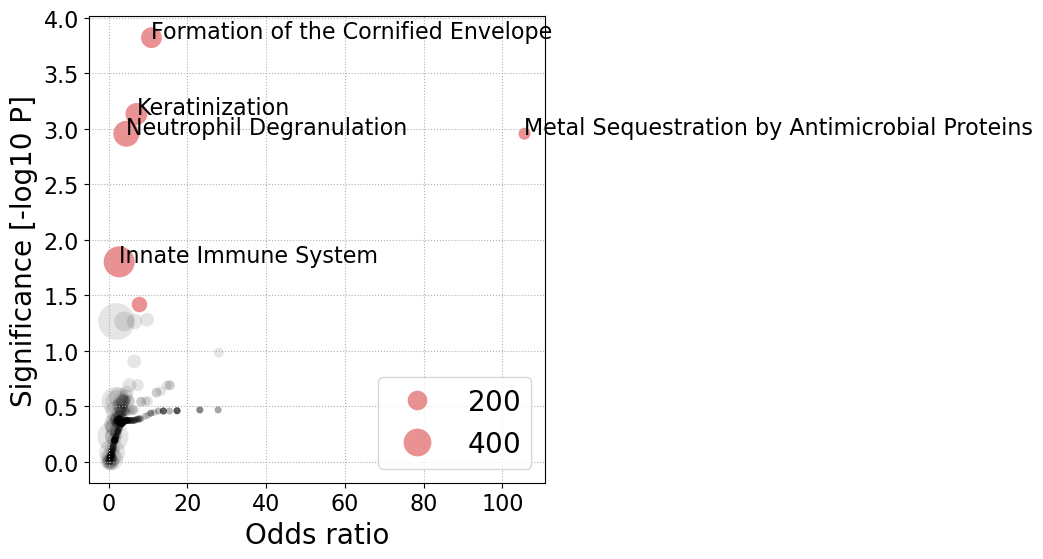

In [10]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))
    
    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='tab:red')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

threshold = importance[numpy.argsort(importance)[::-1][5]] # gimme the top 5
com = c[c['importance'] > threshold]
count = 0
for index, row in com.iterrows():
    x = row['odds_ratio']
    y = -numpy.log10(row['adjusted'])
    
    label = ' '.join(row['term'].split()[:2])
    label = row['term']
    matplotlib.pyplot.text(x, y, label, fontsize=16)
    count = count + 1
    print('{}\t{}\t{}\t{}'.format(count, row['importance'], row['term'], row['adjusted']))

matplotlib.pyplot.legend(*sc.legend_elements("sizes", num=3, color='tab:red', alpha=1/2, mew=0))
matplotlib.pyplot.xlabel('Odds ratio')
matplotlib.pyplot.ylabel('Significance [-log10 P]')
matplotlib.pyplot.grid(ls=':', alpha=1)
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('hom.svg')

In [11]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv('particular2hom.wikipathways.tsv', sep='\t')

d

(6, 7)


,Priority,Adjusted P,Odds ratio,N overlap,Overlap genes
Term,,,,,
Metal Sequestration by Antimicrobial Proteins,1.187292,0.001105,105.633446,3,"Lcn2, S100A9, S100A8"
Formation of the Cornified Envelope,1.063437,0.000150,10.857409,9,"Dsc3, Krt6B, Tgm1, Krt19, Krt15, Krt25, Krt71,..."
Innate Immune System,1.012702,0.015810,2.664190,20,"Iqgap2, Arg1, Pglyrp1, S100A9, S100A8, Lcn2, I..."
Neutrophil Degranulation,0.910307,0.001105,4.479648,14,"Retn, Cfd, Iqgap2, Arg1, Pglyrp1, S100A9, S100..."
Keratinization,0.825361,0.000733,7.037984,10,"Krtap8-1, Krt19, Krt15, Krt25, Dsc3, Krt6B, Tg..."
Antimicrobial Peptides,0.127829,0.038344,7.811983,5,"Cd4, S100A9, S100A8, Lcn2, Pglyrp1"
